
  Data yang diberikan:
  x        f(x)    
  ----------------
  2        3       
  4        5       
  5        1       
  6        6       
  7        9       

  TABEL DIVIDED DIFFERENCE
  x           F[ ]        F[ , ]      F[ , , ]    F[, , , ]   F[, , , , ] 
  ------------------------------------------------------------------------
  2.0000      3.0000      1.0000      -1.6667     1.5417      -0.6750     
  4.0000      5.0000      -4.0000     4.5000      -1.8333     
  5.0000      1.0000      5.0000      -1.0000     
  6.0000      6.0000      3.0000      
  7.0000      9.0000      

  KOEFISIEN POLINOMIAL NEWTON
  fn(x) = F[x0]
        + F[x0,x1](x-x0)
        + F[x0,x1,x2](x-x0)(x-x1)
        + ...

  c0 = tabel[0][0] = 3.000000
  c1 = tabel[0][1] = 1.000000
  c2 = tabel[0][2] = -1.666667
  c3 = tabel[0][3] = 1.541667
  c4 = tabel[0][4] = -0.675000

  HASIL INTERPOLASI PADA x = 3
  f(3) ≈ 12.800000


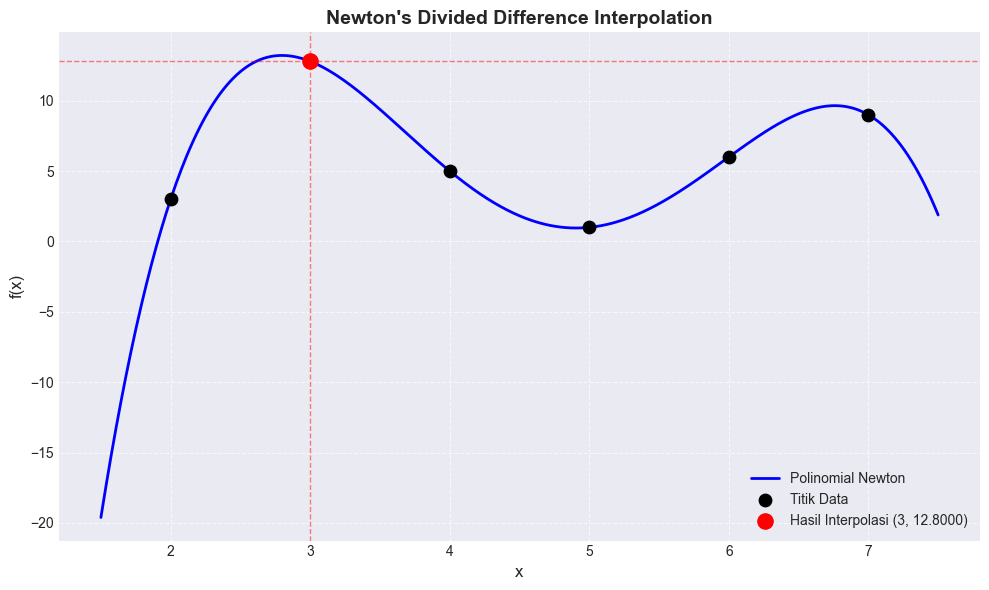

In [1]:
"""
================================================
  INTERPOLASI POLINOMIAL

  Metode: Newton's Divided Difference Interpolation

  Konsep:
    Diberikan n+1 titik data (x0,y0), (x1,y1), ..., (xn,yn),
    cari polinomial derajat <= n yang melewati semua titik:

    fn(x) = F[x0]
           + F[x0,x1](x-x0)
           + F[x0,x1,x2](x-x0)(x-x1)
           + ...
           + F[x0,...,xn](x-x0)(x-x1)...(x-x(n-1))

    Koefisien F[...] disebut Divided Difference.
================================================
"""

import matplotlib.pyplot as plt
import numpy as np


# ── BANGUN TABEL DIVIDED DIFFERENCE ──────────────────────────────────────
def divided_difference(X, Y):
    """
    Membangun tabel divided difference.

    Rumus rekursif:
      F[xi]           = yi
      F[xi, xj]       = (F[xj] - F[xi]) / (xj - xi)
      F[xi,...,xk]    = (F[xi+1,...,xk] - F[xi,...,xk-1]) / (xk - xi)

    Parameters
    ----------
    X : list[float]  -- vektor titik x
    Y : list[float]  -- vektor titik y

    Returns
    -------
    tabel : list[list[float]]  -- tabel divided difference (n x n)
                                  kolom ke-0 = Y asli
                                  kolom ke-k = selisih orde ke-k
    """
    n = len(X)
    tabel = [[0.0] * n for _ in range(n)]

    # kolom pertama = nilai Y
    for i in range(n):
        tabel[i][0] = Y[i]

    # isi kolom selisih
    for j in range(1, n):           # j = orde selisih
        for i in range(n - j):     # i = baris
            tabel[i][j] = (tabel[i+1][j-1] - tabel[i][j-1]) / (X[i+j] - X[i])

    return tabel


# ── CETAK TABEL DIVIDED DIFFERENCE ───────────────────────────────────────
def cetak_tabel(X, tabel):
    n = len(X)
    lebar = 12

    # header
    header = f"  {'x':<{lebar}}"
    for k in range(n):
        if k == 0:
            header += f"{'F[ ]':<{lebar}}"
        elif k == 1:
            header += f"{'F[ , ]':<{lebar}}"
        elif k == 2:
            header += f"{'F[ , , ]':<{lebar}}"
        else:
            label = 'F[' + ', '.join([''] * (k+1)) + ']'
            header += f"{label:<{lebar}}"
    print(header)
    print("  " + "-" * (lebar * (n + 1)))

    # isi tabel
    for i in range(n):
        baris = f"  {X[i]:<{lebar}.4f}"
        for j in range(n - i):
            baris += f"{tabel[i][j]:<{lebar}.4f}"
        print(baris)


# ── EVALUASI POLINOMIAL NEWTON ────────────────────────────────────────────
def newton_interpolate(X, tabel, x_query):
    """
    Mengevaluasi polinomial Newton pada titik x_query.

    fn(x) = c0 + c1*(x-x0) + c2*(x-x0)*(x-x1) + ...
    di mana ci = tabel[0][i] (baris teratas tabel)

    Parameters
    ----------
    X       : list[float]         -- titik x data
    tabel   : list[list[float]]   -- tabel divided difference
    x_query : float               -- titik yang ingin diinterpolasi

    Returns
    -------
    hasil : float -- nilai interpolasi fn(x_query)
    """
    n = len(X)
    hasil = tabel[0][0]     # c0 = F[x0]
    produk = 1.0

    for k in range(1, n):
        produk *= (x_query - X[k-1])
        hasil  += tabel[0][k] * produk

    return hasil


# ── VISUALISASI ───────────────────────────────────────────────────────────
def visualisasi(X, Y, x_query, y_query):
    x_plot = np.linspace(min(X) - 0.5, max(X) + 0.5, 500)
    tabel  = divided_difference(X, Y)
    y_plot = [newton_interpolate(X, tabel, xi) for xi in x_plot]

    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(x_plot, y_plot, color='blue', linewidth=2, label="Polinomial Newton")
    ax.scatter(X, Y, color='black', s=80, zorder=5, label="Titik Data")
    ax.scatter(x_query, y_query, color='red', s=120, zorder=6,
               label=f"Hasil Interpolasi ({x_query}, {y_query:.4f})")
    ax.axvline(x_query, color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.axhline(y_query, color='red', linewidth=1, linestyle='--', alpha=0.5)

    ax.set_title("Newton's Divided Difference Interpolation", fontsize=14, fontweight='bold')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# ── CONTOH SOAL ───────────────────────────────────────────────────────────
if __name__ == "__main__":

    # Data dari slide CISE301 Topic 5:
    #
    # | x | f(x) |
    # | 2 |  3   |
    # | 4 |  5   |
    # | 5 |  1   |
    # | 6 |  6   |
    # | 7 |  9   |
    #
    # Cari polinomial interpolasi, lalu estimasi f(3).

    X = [2, 4, 5, 6, 7]
    Y = [3, 5, 1, 6, 9]
    x_query = 3

    print("\n  Data yang diberikan:")
    print(f"  {'x':<8} {'f(x)':<8}")
    print("  " + "-" * 16)
    for xi, yi in zip(X, Y):
        print(f"  {xi:<8} {yi:<8}")

    # ── Bangun tabel divided difference
    print("\n" + "="*60)
    print("  TABEL DIVIDED DIFFERENCE")
    print("="*60)
    tabel = divided_difference(X, Y)
    cetak_tabel(X, tabel)

    # ── Koefisien polinomial (baris pertama tabel)
    print("\n" + "="*60)
    print("  KOEFISIEN POLINOMIAL NEWTON")
    print("="*60)
    print("  fn(x) = F[x0]")
    print("        + F[x0,x1](x-x0)")
    print("        + F[x0,x1,x2](x-x0)(x-x1)")
    print("        + ...")
    print()
    for k in range(len(X)):
        print(f"  c{k} = tabel[0][{k}] = {tabel[0][k]:.6f}")

    # ── Evaluasi interpolasi
    print("\n" + "="*60)
    print(f"  HASIL INTERPOLASI PADA x = {x_query}")
    print("="*60)
    y_query = newton_interpolate(X, tabel, x_query)
    print(f"  f({x_query}) ≈ {y_query:.6f}")

    # ── Visualisasi
    visualisasi(X, Y, x_query, y_query)